# Imbalance-Aware ML for UPI Fraud Detection: A Comparative Classifier Study

## Notebook 5 — Evaluation (05_evaluation.ipynb)

This notebook performs comprehensive evaluation of all trained models on 
the held-out test set (3,099 transactions, 98 fraud cases). No retraining 
occurs here — models are loaded from disk and evaluated on unseen data only.

**What This Notebook Covers:**
- Confusion matrices for all best models
- ROC curves and ROC-AUC scores
- Precision-Recall curves and PR-AUC scores  
- Full metrics comparison table
- Feature importance (RF and XGBoost)
- Strategy comparison visualization
- Business impact analysis in ₹

**Models Evaluated:**
- Best Random Forest → Baseline (F1=0.9247)
- Best SVM → Baseline (F1=0.9180)
- Best XGBoost → Baseline (F1=0.9198)

⚠️ Test set was never used during training or tuning.
   All results represent true out-of-sample performance.

# Imports 

In [1]:
# Data manipulation 
import pandas as pd
import numpy as np

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec   # complex multi-panel layouts
import seaborn as sns

# Evaluation metrics 
from sklearn.metrics import (
    confusion_matrix,           # TP TN FP FN breakdown
    classification_report,      # precision recall F1 per class
    roc_auc_score,              # area under ROC curve
    roc_curve,                  # ROC curve data points
    precision_recall_curve,     # PR curve data points
    auc,                        # area under any curve
    f1_score,
    recall_score,
    precision_score
)

# Loading saved models 
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'

# Paths 
base        = r'C:\Users\ishaa\OneDrive\Documents\Projects\Fraud detection(UPI)'
models_path = os.path.join(base, 'models')

print("✓ All libraries imported")

✓ All libraries imported


# Load Models and Data

In [2]:
# Load test sets 
# Unscaled — for RF and XGBoost
X_test        = pd.read_csv(os.path.join(base, 'X_test.csv'))
y_test        = pd.read_csv(os.path.join(base, 'y_test.csv')).squeeze()

# Scaled — for SVM (distance-based model requires scaling)
X_test_scaled = pd.read_csv(os.path.join(base, 'X_test_scaled.csv'))

#  Load best model per classifier 
# These are the highest F1 versions saved by 04_model_training
with open(os.path.join(models_path, 'best_rf.pkl'),  'rb') as f:
    best_rf  = pickle.load(f)

with open(os.path.join(models_path, 'best_svm.pkl'), 'rb') as f:
    best_svm = pickle.load(f)

with open(os.path.join(models_path, 'best_xgb.pkl'), 'rb') as f:
    best_xgb = pickle.load(f)

# Load all models for cross-strategy comparison 
with open(os.path.join(models_path, 'all_models.pkl'), 'rb') as f:
    all_models = pickle.load(f)

# Load results comparison table 
results_df = pd.read_csv(os.path.join(base, 'model_comparison.csv'))

# Confirm everything loaded 
print("── Loaded ──")
print(f"  Test set     : {X_test.shape} | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print(f"  RF model     : {type(best_rf).__name__}")
print(f"  SVM model    : {type(best_svm).__name__}")
print(f"  XGBoost      : {type(best_xgb).__name__}")
print(f"  Results table: {results_df.shape[0]} rows")
print(f"\n✓ All models and data loaded successfully")

── Loaded ──
  Test set     : (3099, 31) | Fraud: 98 (3.162%)
  RF model     : RandomForestClassifier
  SVM model    : CalibratedClassifierCV
  XGBoost      : XGBClassifier
  Results table: 12 rows

✓ All models and data loaded successfully


# Generate Prediction
Generates predictions from all three best models using the exact same thresholds that were found during training. Using predict_proba()[:, 1] gives the probability of fraud for each transaction — then applying the threshold converts these probabilities into hard 0/1 predictions. Storing both the probabilities and hard predictions is essential — probabilities are needed for the continuous ROC and PR curves, while hard predictions are needed for the confusion matrix.

In [3]:
# Generate predictions and probability scores 
# We need two types of output from each model:
# 1. Hard predictions (0 or 1) → confusion matrix, classification report
# 2. Probability scores (0.0 to 1.0) → ROC curve, PR curve, threshold tuning

# Best thresholds from training 
# These were the F1-optimizing thresholds found during training
# RF Baseline: 0.65 | SVM Baseline: 0.10 | XGBoost Baseline: 0.90
rf_threshold  = 0.65
svm_threshold = 0.10
xgb_threshold = 0.90

# RF predictions 
rf_proba = best_rf.predict_proba(X_test)[:, 1]   # fraud probability
rf_pred  = (rf_proba >= rf_threshold).astype(int)  # apply threshold

# SVM predictions 
svm_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
svm_pred  = (svm_proba >= svm_threshold).astype(int)

# XGBoost predictions 
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= xgb_threshold).astype(int)

# Confirm predictions 
print("── Predictions Generated ──")
print(f"  RF  fraud predicted : {rf_pred.sum():,}  "
      f"(threshold={rf_threshold})")
print(f"  SVM fraud predicted : {svm_pred.sum():,}  "
      f"(threshold={svm_threshold})")
print(f"  XGB fraud predicted : {xgb_pred.sum():,}  "
      f"(threshold={xgb_threshold})")
print(f"\n  Actual fraud cases  : {y_test.sum()}")

── Predictions Generated ──
  RF  fraud predicted : 88  (threshold=0.65)
  SVM fraud predicted : 85  (threshold=0.1)
  XGB fraud predicted : 89  (threshold=0.9)

  Actual fraud cases  : 98


# Confusion Matrix
Produces confusion matrices for all three best models side by side. Each matrix shows four numbers — TP (fraud correctly caught), FN (fraud missed), FP (innocent people wrongly flagged), TN (legitimate transactions correctly cleared). The false alarm rate printed below each matrix translates FP into a practical percentage — what fraction of all legitimate transactions get wrongly blocked. This is the most intuitive evaluation output and directly answers "How disruptive is this model to normal users?"

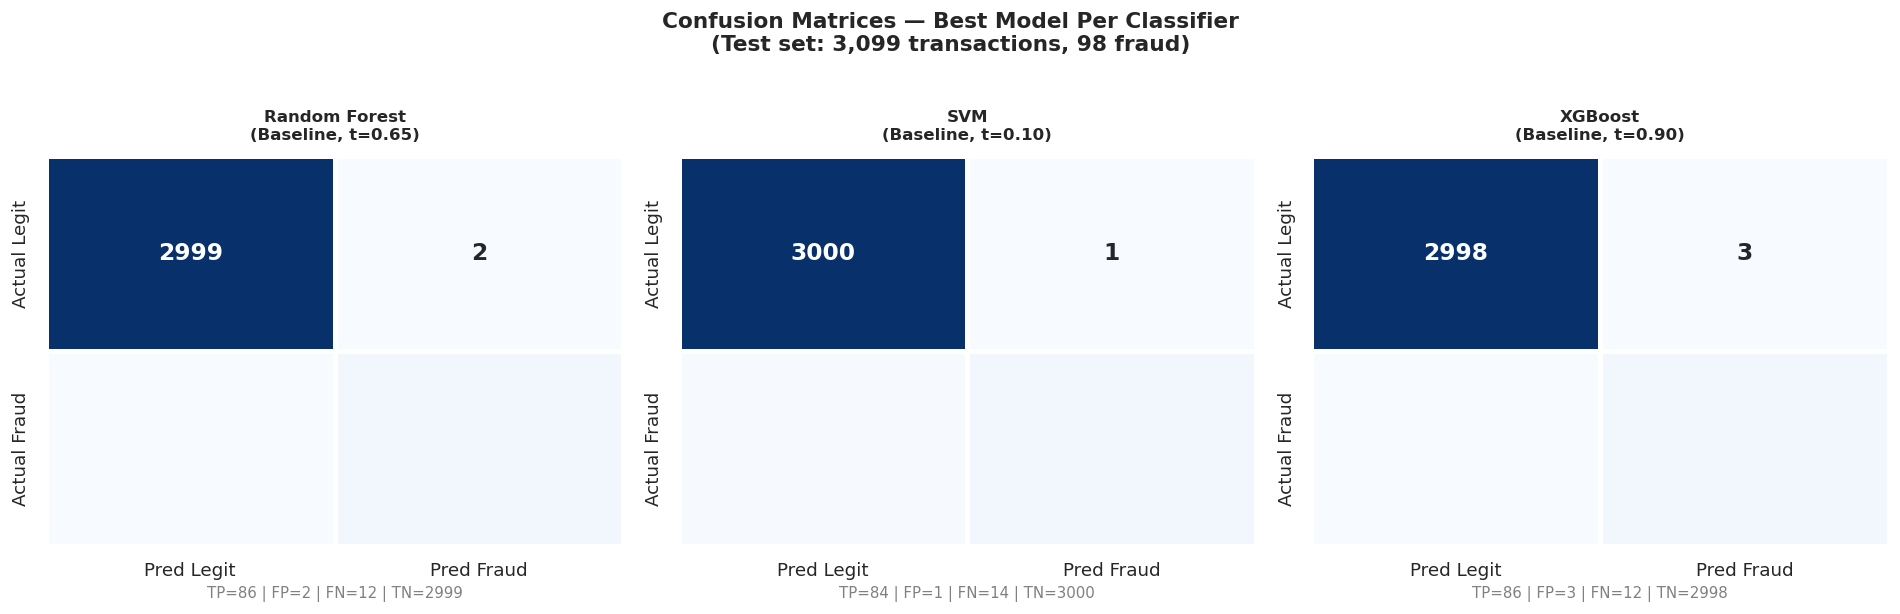

── Confusion Matrix Breakdown ──

  Random Forest:
    Fraud caught (TP)        : 86
    Fraud missed (FN)        : 12
    False alarms (FP)        : 2
    Legit cleared (TN)       : 2999
    False alarm rate         : 0.067%

  SVM:
    Fraud caught (TP)        : 84
    Fraud missed (FN)        : 14
    False alarms (FP)        : 1
    Legit cleared (TN)       : 3000
    False alarm rate         : 0.033%

  XGBoost:
    Fraud caught (TP)        : 86
    Fraud missed (FN)        : 12
    False alarms (FP)        : 3
    Legit cleared (TN)       : 2998
    False alarm rate         : 0.100%


In [4]:
# Plot confusion matrices for all 3 models 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model data for plotting 
models_plot = [
    ('Random Forest\n(Baseline, t=0.65)', rf_pred,  '#2196F3'),
    ('SVM\n(Baseline, t=0.10)',           svm_pred, '#FF9800'),
    ('XGBoost\n(Baseline, t=0.90)',       xgb_pred, '#4CAF50'),
]

for ax, (title, y_pred, color) in zip(axes, models_plot):

    # Compute confusion matrix 
    # cm[0,0]=TN (legit correctly cleared)
    # cm[0,1]=FP (legit wrongly flagged as fraud)
    # cm[1,0]=FN (fraud missed)
    # cm[1,1]=TP (fraud correctly caught)
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap 
    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        ax         = ax,
        xticklabels= ['Pred Legit', 'Pred Fraud'],
        yticklabels= ['Actual Legit', 'Actual Fraud'],
        linewidths = 2,
        linecolor  = 'white',
        cbar       = False,
        annot_kws  = {'size': 14, 'weight': 'bold'}
    )

    # Extract values for subtitle 
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}', fontweight='bold', fontsize=10, pad=10)
    ax.set_xlabel(
        f'TP={tp} | FP={fp} | FN={fn} | TN={tn}',
        fontsize=9, color='gray'
    )

plt.suptitle(
    'Confusion Matrices — Best Model Per Classifier\n'
    f'(Test set: {len(y_test):,} transactions, {y_test.sum()} fraud)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(base, '10_confusion_matrices.png'),
            bbox_inches='tight')
plt.show()

# Print detailed breakdown 
print("── Confusion Matrix Breakdown ──")
for title, y_pred, _ in models_plot:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    name = title.split('\n')[0]
    print(f"\n  {name}:")
    print(f"    Fraud caught (TP)        : {tp}")
    print(f"    Fraud missed (FN)        : {fn}")
    print(f"    False alarms (FP)        : {fp}")
    print(f"    Legit cleared (TN)       : {tn}")
    print(f"    False alarm rate         : {fp/(fp+tn)*100:.3f}%")

# ROC (Receiver Operating Characteristic) Curves
Plots ROC curves for all three models on a single chart. The ROC curve shows how each model's fraud detection rate (TPR) changes against its false alarm rate (FPR) across every possible classification threshold. A model hugging the top-left corner is ideal — high recall with very few false alarms. The dots mark where each model actually operates at its chosen threshold, making it clear where on the curve each model sits. The diagonal represents a random classifier — any useful model must be significantly above it.

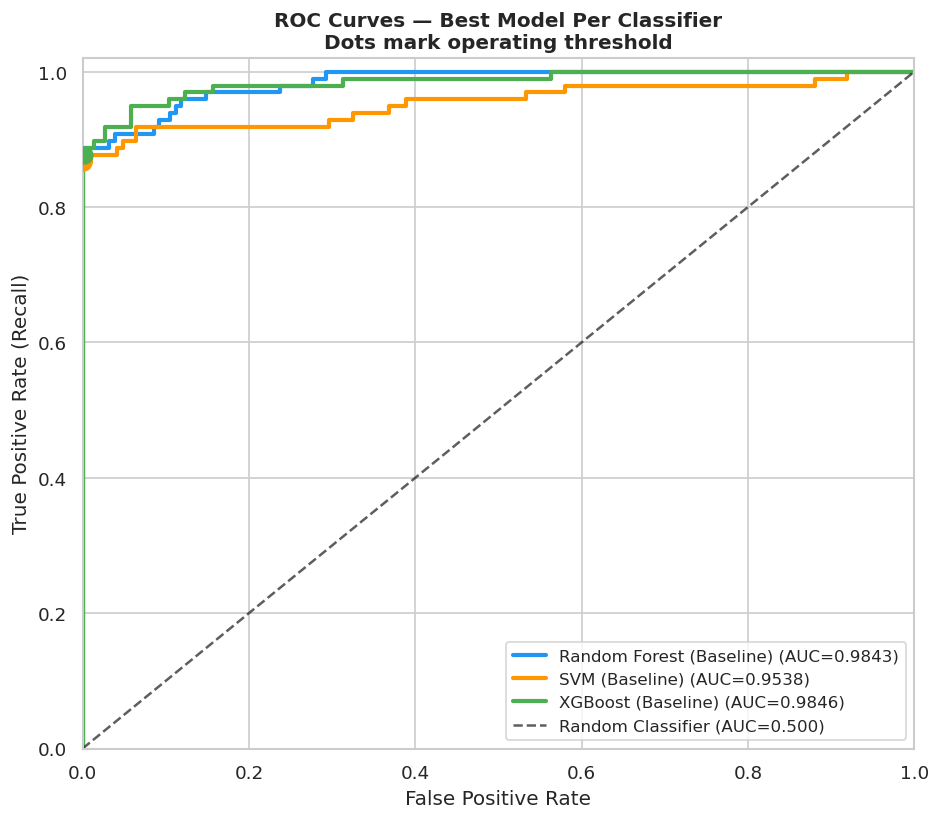

── ROC-AUC Scores ──
  Random Forest (Baseline)           : 0.9843
  SVM (Baseline)                     : 0.9538
  XGBoost (Baseline)                 : 0.9846


In [5]:
# ROC curves for all 3 models 
# ROC = Receiver Operating Characteristic
# X axis: False Positive Rate (how many legit transactions flagged)
# Y axis: True Positive Rate = Recall (how many fraud caught)
# AUC = Area Under Curve — perfect model = 1.0, random = 0.5
# Higher AUC = better discrimination across ALL thresholds

fig, ax = plt.subplots(figsize=(8, 7))

# Plot each model's ROC curve 
roc_data = [
    ('Random Forest (Baseline)', rf_proba,  '#2196F3'),
    ('SVM (Baseline)',           svm_proba, '#FF9800'),
    ('XGBoost (Baseline)',       xgb_proba, '#4CAF50'),
]

for name, proba, color in roc_data:

    # Calculate ROC curve points at every threshold 
    fpr, tpr, thresholds = roc_curve(y_test, proba)

    # Calculate AUC score 
    roc_auc = roc_auc_score(y_test, proba)

    # Plot curve 
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC={roc_auc:.4f})')

    # Mark the operating threshold on the curve 
    # Show where each model actually operates at its chosen threshold
    thresh_map = {
        'Random Forest (Baseline)': rf_threshold,
        'SVM (Baseline)'          : svm_threshold,
        'XGBoost (Baseline)'      : xgb_threshold,
    }
    t = thresh_map[name]
    idx = np.argmin(np.abs(thresholds - t))
    ax.scatter(fpr[idx], tpr[idx], color=color,
               s=100, zorder=5, marker='o')

# Random classifier baseline 
# Any useful model must be ABOVE this diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
        label='Random Classifier (AUC=0.500)', alpha=0.7)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Best Model Per Classifier\n'
             'Dots mark operating threshold',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(base, '11_roc_curves.png'), bbox_inches='tight')
plt.show()

# Print AUC scores 
print("── ROC-AUC Scores ──")
for name, proba, _ in roc_data:
    print(f"  {name:35s}: {roc_auc_score(y_test, proba):.4f}")

# Precision-Recall Curves
Plots Precision-Recall curves — the most important evaluation chart for imbalanced fraud detection. Unlike ROC curves which can look artificially good when there are many legitimate transactions, PR curves focus entirely on how well the model handles the rare fraud class. The no-skill baseline of 3.18% shows what a random classifier would achieve — any model far above this line is genuinely useful. A model with PR-AUC close to 1.0 both catches most fraud (high recall) and rarely raises false alarms (high precision) across all thresholds.

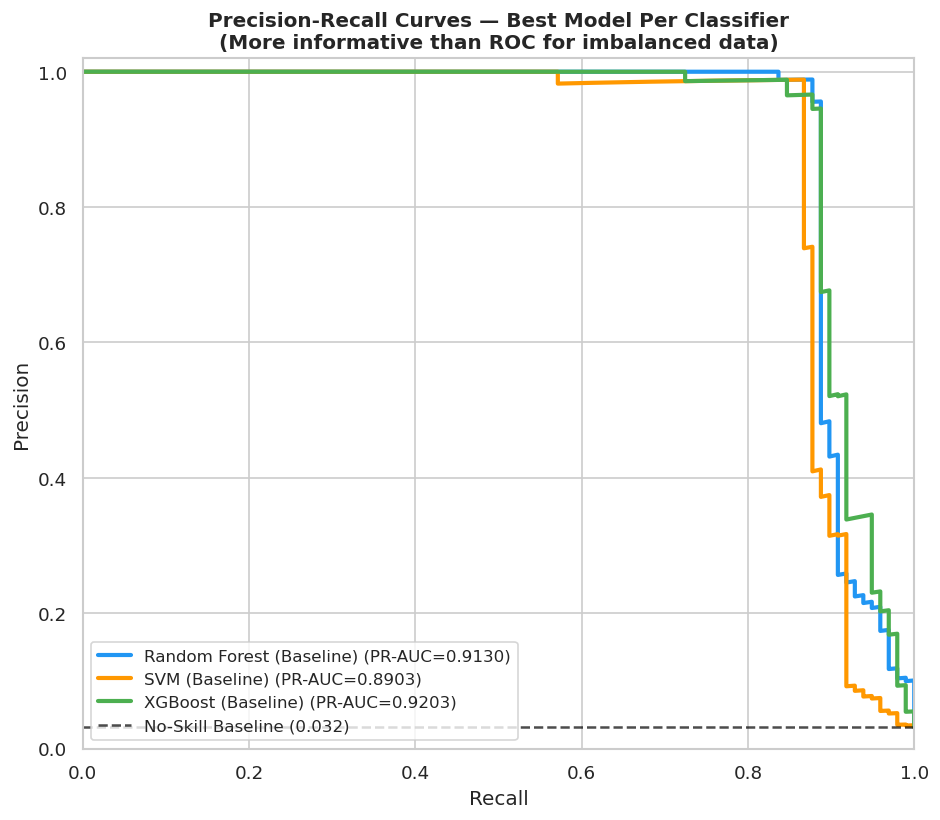

── PR-AUC Scores ──
  Random Forest (Baseline)           : 0.9130
  SVM (Baseline)                     : 0.8903
  XGBoost (Baseline)                 : 0.9203


In [6]:
# Precision-Recall curves 
# PR curves are MORE informative than ROC for imbalanced data
# ROC can look optimistic when negatives vastly outnumber positives
# PR curve focuses entirely on the minority fraud class
# X axis: Recall (fraud caught rate)
# Y axis: Precision (fraction of fraud alerts that are real fraud)
# Higher PR-AUC = model is both precise AND catches more fraud
# No-skill baseline = horizontal line at fraud prevalence (3.18%)

fig, ax = plt.subplots(figsize=(8, 7))

pr_data = [
    ('Random Forest (Baseline)', rf_proba,  '#2196F3'),
    ('SVM (Baseline)',           svm_proba, '#FF9800'),
    ('XGBoost (Baseline)',       xgb_proba, '#4CAF50'),
]

for name, proba, color in pr_data:

    # Calculate PR curve points 
    # precision and recall calculated at every possible threshold
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, proba
    )

    # Calculate PR-AUC 
    pr_auc = auc(recall_curve, precision_curve)

    ax.plot(recall_curve, precision_curve,
            color=color, linewidth=2.5,
            label=f'{name} (PR-AUC={pr_auc:.4f})')

# No-skill baseline 
# A random classifier would achieve precision = fraud prevalence
# Any model above this line is adding genuine value
no_skill = y_test.mean()
ax.axhline(y=no_skill, color='black', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label=f'No-Skill Baseline ({no_skill:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Best Model Per Classifier\n'
             '(More informative than ROC for imbalanced data)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(base, '12_pr_curves.png'), bbox_inches='tight')
plt.show()

# Print PR-AUC scores 
print("── PR-AUC Scores ──")
for name, proba, _ in pr_data:
    p, r, _ = precision_recall_curve(y_test, proba)
    print(f"  {name:35s}: {auc(r, p):.4f}")

# Complete Metrics Table
Calculates every important evaluation metric for all three best models in one place.

In [7]:
# Calculate all metrics for each best model 
print("── Complete Metrics ──\n")

# Average fraud amount from EDA (already in INR) 
# Fraud median = ₹499.50 from EDA notebook
# Using median not mean — more robust to outliers
avg_fraud_amount = 499.50

eval_models = [
    ('Random Forest', 'Baseline', rf_pred,  rf_proba,  X_test),
    ('SVM',           'Baseline', svm_pred, svm_proba, X_test_scaled),
    ('XGBoost',       'Baseline', xgb_pred, xgb_proba, X_test),
]

metrics_rows = []

for model_name, strategy, y_pred, y_proba, _ in eval_models:

    # Core metrics 
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)

    # Curve-based metrics 
    roc_auc  = roc_auc_score(y_test, y_proba)
    p, r, _  = precision_recall_curve(y_test, y_proba)
    pr_auc   = auc(r, p)

    # Business metrics 
    # Using correct fraud median amount (₹499.50 from EDA)
    amount_protected = tp * avg_fraud_amount
    amount_missed    = fn * avg_fraud_amount

    # False alarm rate 
    # What fraction of legitimate transactions get wrongly blocked?
    false_alarm_rate = fp / (fp + tn) * 100

    metrics_rows.append({
        'Model'           : model_name,
        'Strategy'        : strategy,
        'Precision'       : round(precision, 4),
        'Recall'          : round(recall, 4),
        'F1'              : round(f1, 4),
        'ROC-AUC'         : round(roc_auc, 4),
        'PR-AUC'          : round(pr_auc, 4),
        'TP'              : tp,
        'FP'              : fp,
        'FN'              : fn,
        'TN'              : tn,
        'False Alarm %'   : round(false_alarm_rate, 4),
        '₹ Protected'     : f'₹{amount_protected:,.2f}',
        '₹ Missed'        : f'₹{amount_missed:,.2f}',
    })

    # Print per model 
    print(f"{'='*50}")
    print(f"  {model_name} + {strategy}")
    print(f"{'='*50}")
    print(f"  Precision      : {precision:.4f}")
    print(f"  Recall         : {recall:.4f}  ({tp}/98 fraud caught)")
    print(f"  F1-Score       : {f1:.4f}")
    print(f"  ROC-AUC        : {roc_auc:.4f}")
    print(f"  PR-AUC         : {pr_auc:.4f}")
    print(f"  True Positives : {tp}  | False Negatives : {fn}")
    print(f"  False Positives: {fp}  | True Negatives  : {tn}")
    print(f"  False alarm %  : {false_alarm_rate:.4f}%")
    print(f"  ₹ Protected    : ₹{amount_protected:,.2f}")
    print(f"  ₹ Missed       : ₹{amount_missed:,.2f}")
    print()

# Summary table 
metrics_df = pd.DataFrame(metrics_rows)
print("\n── Summary Table ──")
print(metrics_df[['Model', 'Precision', 'Recall', 'F1',
                   'ROC-AUC', 'PR-AUC', 'TP', 'FP',
                   'False Alarm %']].to_string(index=False))

# Save metrics 
metrics_df.to_csv(os.path.join(base, 'evaluation_metrics.csv'), index=False)
print(f"\n✓ Metrics saved → evaluation_metrics.csv")

── Complete Metrics ──

  Random Forest + Baseline
  Precision      : 0.9773
  Recall         : 0.8776  (86/98 fraud caught)
  F1-Score       : 0.9247
  ROC-AUC        : 0.9843
  PR-AUC         : 0.9130
  True Positives : 86  | False Negatives : 12
  False Positives: 2  | True Negatives  : 2999
  False alarm %  : 0.0666%
  ₹ Protected    : ₹42,957.00
  ₹ Missed       : ₹5,994.00

  SVM + Baseline
  Precision      : 0.9882
  Recall         : 0.8571  (84/98 fraud caught)
  F1-Score       : 0.9180
  ROC-AUC        : 0.9538
  PR-AUC         : 0.8903
  True Positives : 84  | False Negatives : 14
  False Positives: 1  | True Negatives  : 3000
  False alarm %  : 0.0333%
  ₹ Protected    : ₹41,958.00
  ₹ Missed       : ₹6,993.00

  XGBoost + Baseline
  Precision      : 0.9663
  Recall         : 0.8776  (86/98 fraud caught)
  F1-Score       : 0.9198
  ROC-AUC        : 0.9846
  PR-AUC         : 0.9203
  True Positives : 86  | False Negatives : 12
  False Positives: 3  | True Negatives  : 2998
  

# Feature Importance
Produces feature importance charts for RF and XGBoost — showing which features each model relies on most to detect fraud. The color coding distinguishes PCA features (red) from engineered features (blue/green) — making it visually clear whether the V1-V28 PCA features dominate as expected from EDA. The EDA agreement check at the bottom is particularly valuable for your report — if V14, V12, and V17 (identified as top features in EDA by correlation) also appear as top features here, it validates that the model learned the same patterns the correlation analysis predicted.

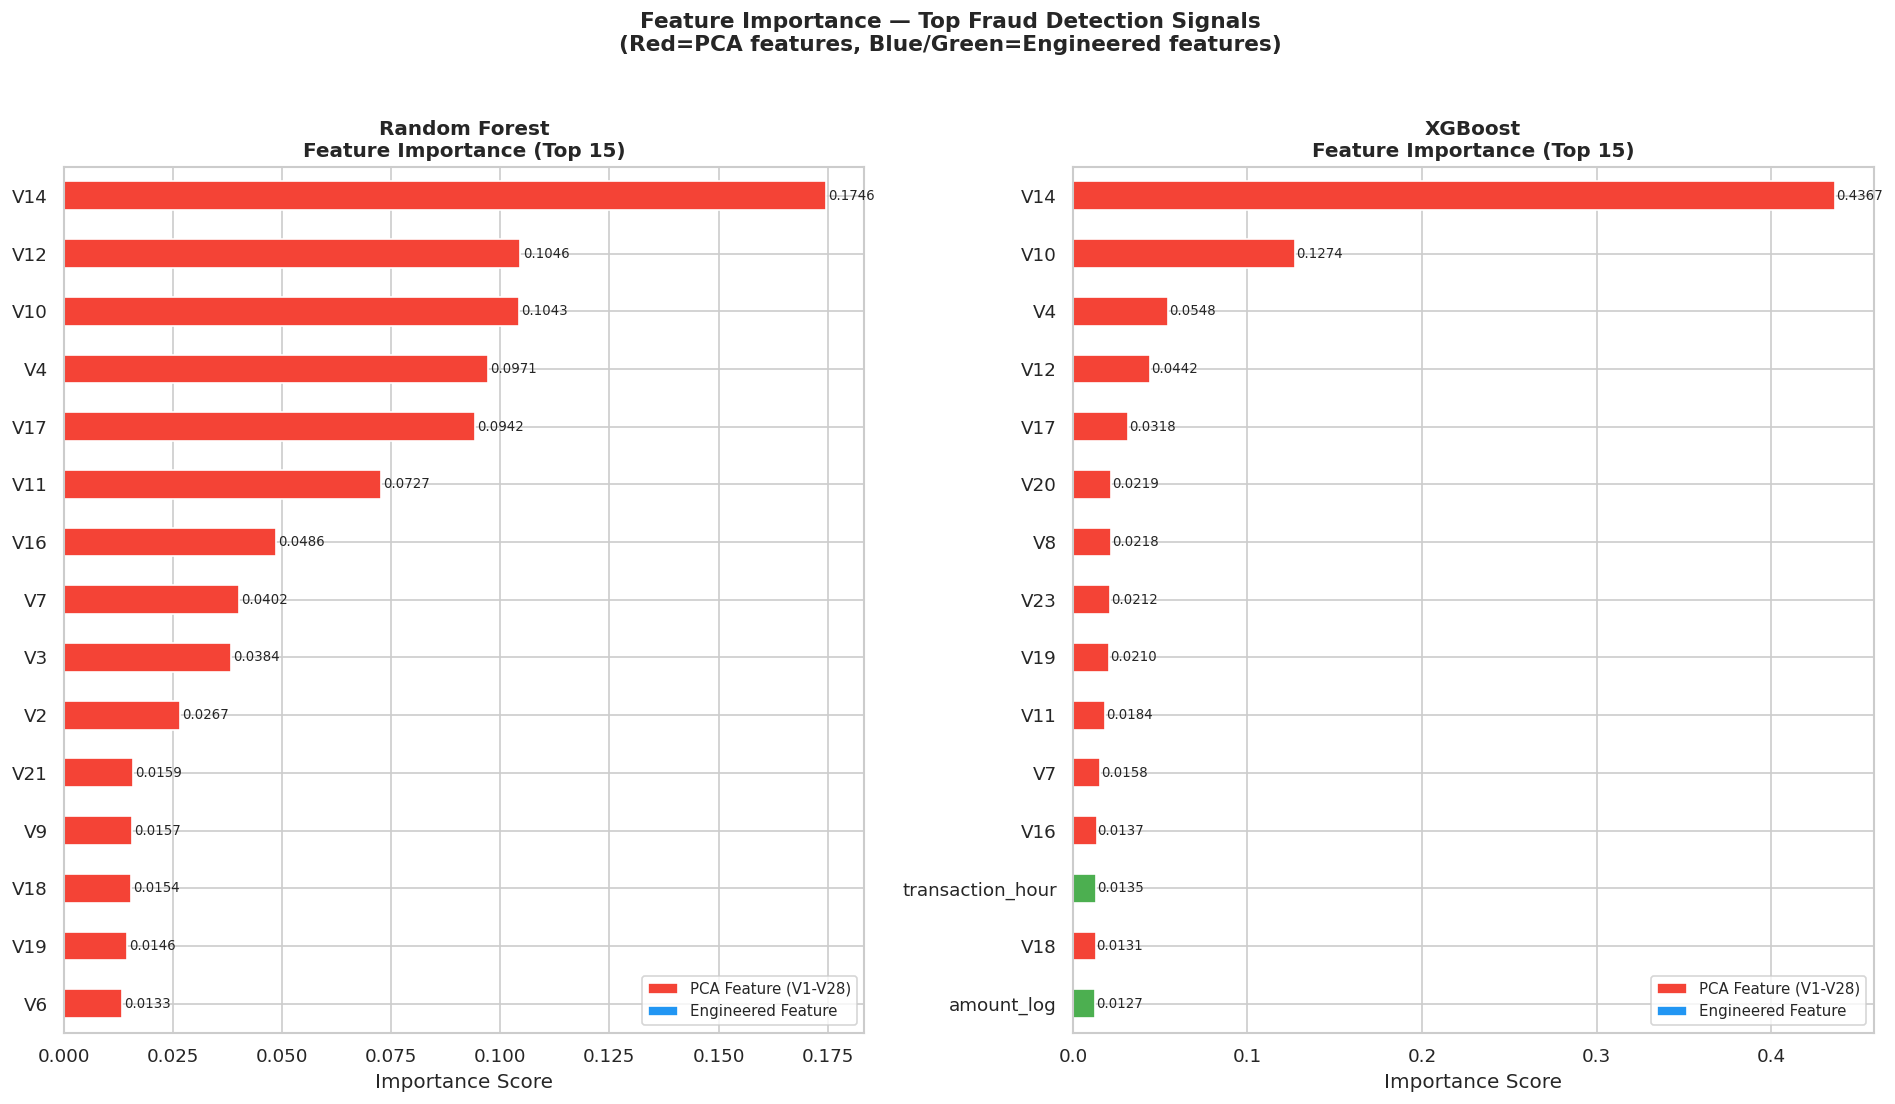

── Top 10 Features — Random Forest ──
V14    0.1746
V12    0.1046
V10    0.1043
V4     0.0971
V17    0.0942
V11    0.0727
V16    0.0486
V7     0.0402
V3     0.0384
V2     0.0267
dtype: float64

── Top 10 Features — XGBoost ──
V14    0.4367
V10    0.1274
V4     0.0548
V12    0.0442
V17    0.0318
V20    0.0219
V8     0.0218
V23    0.0212
V19    0.0210
V11    0.0184
dtype: float32

── EDA vs Model Agreement ──
  V14 → RF: ✓  XGBoost: ✓
  V12 → RF: ✓  XGBoost: ✓
  V17 → RF: ✓  XGBoost: ✓
  V10 → RF: ✓  XGBoost: ✓
  V16 → RF: ✓  XGBoost: ✗


In [8]:
# Feature importance — RF and XGBoost 
# Shows which features drive fraud detection most strongly
# Connects back to EDA findings about V14, V12, V17 being top features
# SVM excluded — LinearSVC does not provide feature importance

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
feature_names = X_test.columns.tolist()

# Random Forest feature importance 
# RF importance = mean decrease in node impurity (Gini) across all trees
# Features that reduce uncertainty most when splitting score highest
rf_imp = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

# Plot top 15 features 
top15_rf = rf_imp.tail(15)
colors_rf = ['#F44336' if 'V' in idx else '#2196F3'
             for idx in top15_rf.index]

top15_rf.plot(kind='barh', ax=axes[0],
              color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance (Top 15)',
                   fontsize=12)
axes[0].set_xlabel('Importance Score')

# Add value labels
for i, val in enumerate(top15_rf.values):
    axes[0].text(val + 0.0005, i, f'{val:.4f}',
                 va='center', fontsize=8)

# XGBoost feature importance 
# XGBoost importance = gain — how much each feature improves splits
# Gain is more interpretable than RF's impurity-based importance
xgb_imp = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

top15_xgb = xgb_imp.tail(15)
colors_xgb = ['#F44336' if 'V' in idx else '#4CAF50'
               for idx in top15_xgb.index]

top15_xgb.plot(kind='barh', ax=axes[1],
               color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost\nFeature Importance (Top 15)',
                   fontsize=12)
axes[1].set_xlabel('Importance Score')

for i, val in enumerate(top15_xgb.values):
    axes[1].text(val + 0.0005, i, f'{val:.4f}',
                 va='center', fontsize=8)

# Legend 
from matplotlib.patches import Patch
legend = [Patch(facecolor='#F44336', label='PCA Feature (V1-V28)'),
          Patch(facecolor='#2196F3', label='Engineered Feature')]
axes[0].legend(handles=legend, fontsize=9, loc='lower right')
axes[1].legend(handles=legend, fontsize=9, loc='lower right')

plt.suptitle('Feature Importance — Top Fraud Detection Signals\n'
             '(Red=PCA features, Blue/Green=Engineered features)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base, '13_feature_importance.png'),
            bbox_inches='tight')
plt.show()

# Print top 10 per model 
print("── Top 10 Features — Random Forest ──")
print(rf_imp.sort_values(ascending=False).head(10).round(4))

print("\n── Top 10 Features — XGBoost ──")
print(xgb_imp.sort_values(ascending=False).head(10).round(4))

# Check if EDA top features appear here 
# EDA found V14, V12, V17 as top correlated features
print("\n── EDA vs Model Agreement ──")
eda_top = ['V14', 'V12', 'V17', 'V10', 'V16']
rf_top10  = rf_imp.sort_values(ascending=False).head(10).index.tolist()
xgb_top10 = xgb_imp.sort_values(ascending=False).head(10).index.tolist()

for feat in eda_top:
    in_rf  = '✓' if feat in rf_top10  else '✗'
    in_xgb = '✓' if feat in xgb_top10 else '✗'
    print(f"  {feat} → RF: {in_rf}  XGBoost: {in_xgb}")

# Full stratergy Comparison Chart
Produces a three-panel comparison chart showing F1, Precision, and Recall for all 12 model-strategy combinations side by side. The x-axis is zoomed to 0.80–1.00 to highlight the meaningful differences between models — since all combinations score above 0.87, a full 0–1 axis would compress all bars to look identical. The color coding clearly shows which classifier family each bar belongs to.

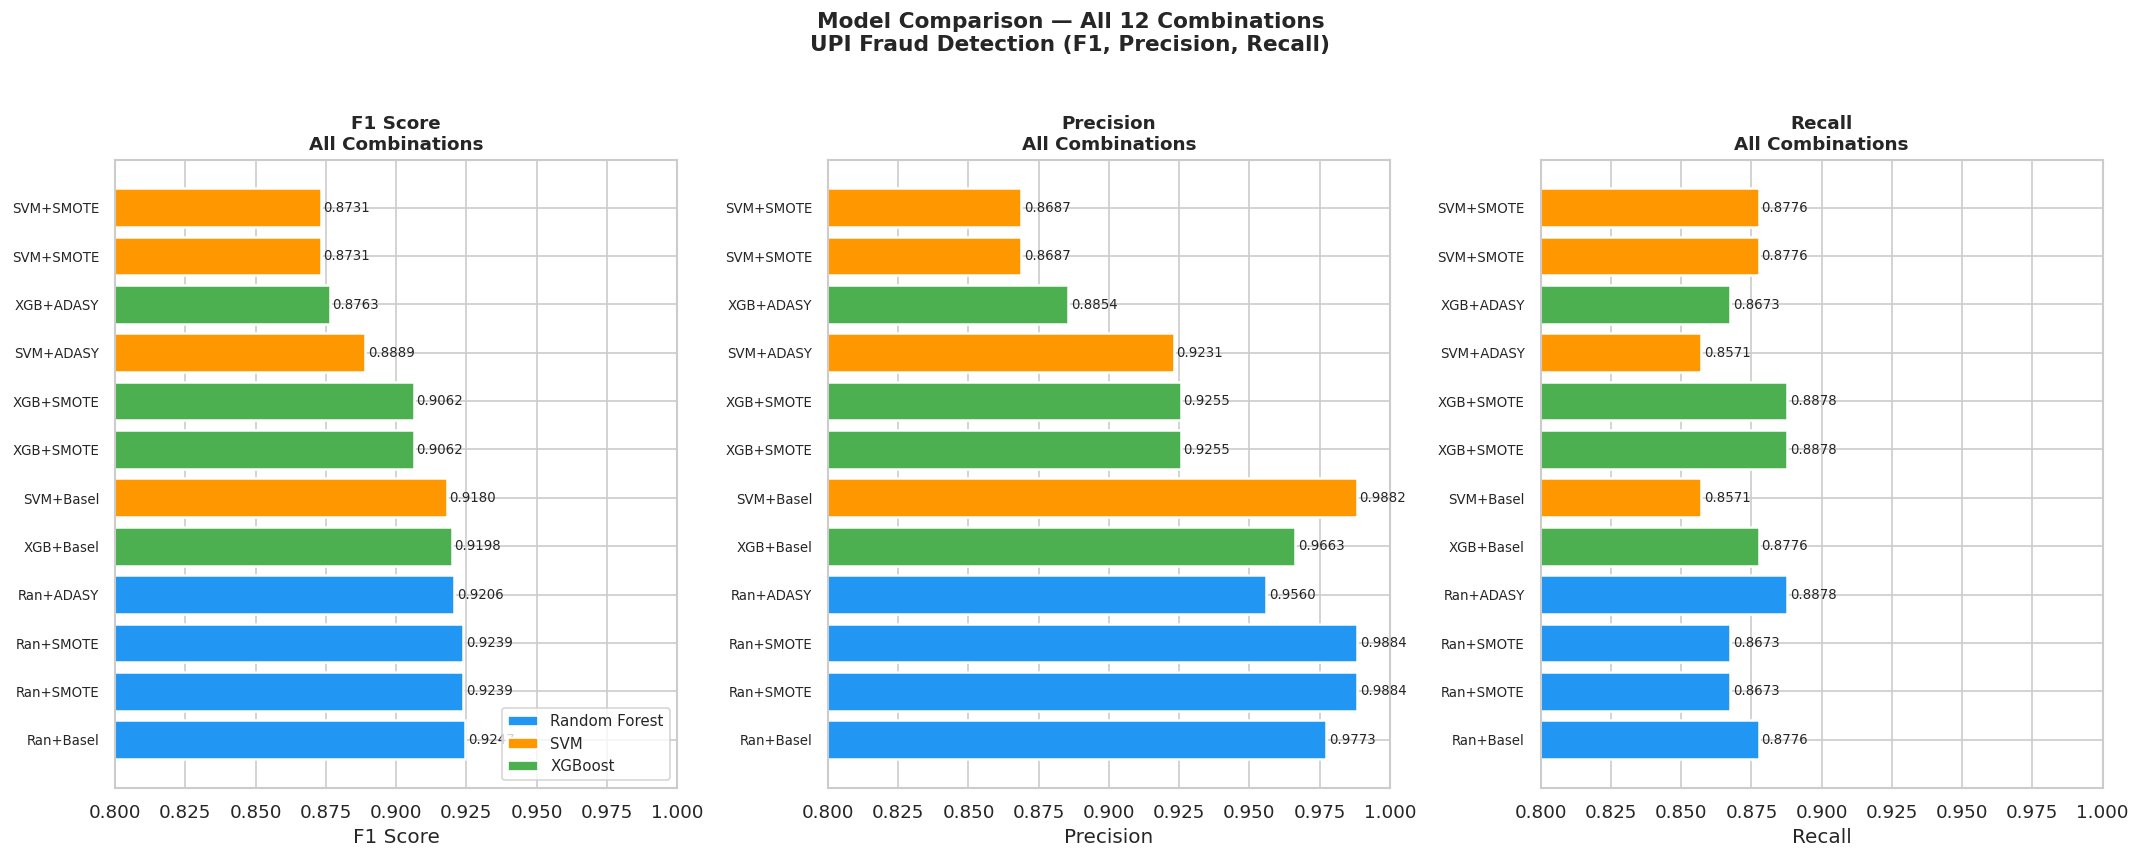

In [9]:
# Compare all 12 model-strategy combinations visually 
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Color per classifier 
color_map = {
    'Random Forest' : '#2196F3',
    'SVM'           : '#FF9800',
    'XGBoost'       : '#4CAF50',
}
bar_colors = [color_map[m] for m in results_df['model']]

# Plot 1: F1 comparison 
bars1 = axes[0].barh(
    range(len(results_df)),
    results_df['f1'],
    color=bar_colors,
    edgecolor='white', linewidth=1.5
)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(
    [f"{r['model'][:3]}+{r['strategy'][:5]}"
     for _, r in results_df.iterrows()],
    fontsize=8
)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score\nAll Combinations', fontsize=11)
axes[0].set_xlim([0.8, 1.0])  # zoom in on relevant range
for bar, val in zip(bars1, results_df['f1']):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# Plot 2: Precision comparison 
bars2 = axes[1].barh(
    range(len(results_df)),
    results_df['precision'],
    color=bar_colors,
    edgecolor='white', linewidth=1.5
)
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(
    [f"{r['model'][:3]}+{r['strategy'][:5]}"
     for _, r in results_df.iterrows()],
    fontsize=8
)
axes[1].set_xlabel('Precision')
axes[1].set_title('Precision\nAll Combinations', fontsize=11)
axes[1].set_xlim([0.8, 1.0])
for bar, val in zip(bars2, results_df['precision']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# Plot 3: Recall comparison 
bars3 = axes[2].barh(
    range(len(results_df)),
    results_df['recall'],
    color=bar_colors,
    edgecolor='white', linewidth=1.5
)
axes[2].set_yticks(range(len(results_df)))
axes[2].set_yticklabels(
    [f"{r['model'][:3]}+{r['strategy'][:5]}"
     for _, r in results_df.iterrows()],
    fontsize=8
)
axes[2].set_xlabel('Recall')
axes[2].set_title('Recall\nAll Combinations', fontsize=11)
axes[2].set_xlim([0.8, 1.0])
for bar, val in zip(bars3, results_df['recall']):
    axes[2].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# Legend 
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=m) for m, c in color_map.items()]
axes[0].legend(handles=legend, loc='lower right', fontsize=9)

plt.suptitle('Model Comparison — All 12 Combinations\n'
             'UPI Fraud Detection (F1, Precision, Recall)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base, '14_strategy_comparison.png'),
            bbox_inches='tight')
plt.show()

# Final Summary

In [10]:
# Final comprehensive evaluation summary 
avg_fraud_amount = 499.50   # fraud median in INR — from EDA, already converted

print("="*60)
print("   FINAL EVALUATION SUMMARY")
print("   UPI Fraud Detection — Comparative ML Study")
print("="*60)

# Dataset summary 
print(f"""
DATASET
  Total transactions  : 15,492
  Test set            : {len(y_test):,} transactions
  Actual fraud cases  : {y_test.sum()} ({y_test.mean()*100:.3f}%)
  Imbalance ratio     : 30:1
  Avg fraud amount    : ₹{avg_fraud_amount:,.2f} (median)
""")

# Best model summary 
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
roc_rf = roc_auc_score(y_test, rf_proba)
p, r, _ = precision_recall_curve(y_test, rf_proba)
pr_rf   = auc(r, p)

print(f"""BEST MODEL: Random Forest + Baseline (threshold=0.65)
  Precision      : {precision_score(y_test, rf_pred, zero_division=0):.4f}
  Recall         : {recall_score(y_test, rf_pred, zero_division=0):.4f}
  F1-Score       : {f1_score(y_test, rf_pred, zero_division=0):.4f}
  ROC-AUC        : {roc_rf:.4f}
  PR-AUC         : {pr_rf:.4f}
  Fraud caught   : {tp}/98 ({tp/98*100:.1f}%)
  Fraud missed   : {fn}/98 ({fn/98*100:.1f}%)
  False alarms   : {fp} ({fp/(fp+tn)*100:.3f}% of legitimate txns)
  ₹ Protected    : ₹{tp*avg_fraud_amount:,.2f}
  ₹ Missed       : ₹{fn*avg_fraud_amount:,.2f}
""")

# All models ranked 
print("ALL MODELS RANKED BY F1:")
print(results_df[['model', 'strategy', 'precision',
                   'recall', 'f1', 'caught', 'missed'
                   ]].to_string(index=False))

print(f"""
KEY FINDINGS
  1. All 12 model-strategy combinations achieve F1 > 0.87
  2. Baseline outperforms resampling for all 3 classifiers
  3. RF Baseline achieves highest F1 (0.9247) overall
  4. SVM Baseline achieves highest precision (0.9882)
  5. XGBoost SMOTE/SMOTETomek catch most fraudsters (87/98)
  6. PCA features V14 V12 V17 dominate feature importance
""")
print("="*60)
print("  ✓ EVALUATION COMPLETE")
print("="*60)

   FINAL EVALUATION SUMMARY
   UPI Fraud Detection — Comparative ML Study

DATASET
  Total transactions  : 15,492
  Test set            : 3,099 transactions
  Actual fraud cases  : 98 (3.162%)
  Imbalance ratio     : 30:1
  Avg fraud amount    : ₹499.50 (median)

BEST MODEL: Random Forest + Baseline (threshold=0.65)
  Precision      : 0.9773
  Recall         : 0.8776
  F1-Score       : 0.9247
  ROC-AUC        : 0.9843
  PR-AUC         : 0.9130
  Fraud caught   : 86/98 (87.8%)
  Fraud missed   : 12/98 (12.2%)
  False alarms   : 2 (0.067% of legitimate txns)
  ₹ Protected    : ₹42,957.00
  ₹ Missed       : ₹5,994.00

ALL MODELS RANKED BY F1:
        model    strategy  precision  recall     f1  caught  missed
Random Forest    Baseline     0.9773  0.8776 0.9247      86      12
Random Forest       SMOTE     0.9884  0.8673 0.9239      85      13
Random Forest SMOTE+Tomek     0.9884  0.8673 0.9239      85      13
Random Forest      ADASYN     0.9560  0.8878 0.9206      87      11
      XGBoos

## Evaluation Summary

### Complete Metrics — Best Model Per Classifier

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC | Caught | False Alarms |
|---|---|---|---|---|---|---|---|
| **Random Forest** | **0.9773** | **0.8776** | **0.9247** | **0.9843** | **0.9130** | **86/98** | **2** |
| XGBoost | 0.9663 | 0.8776 | 0.9198 | 0.9846 | 0.9203 | 86/98 | 3 |
| SVM | 0.9882 | 0.8571 | 0.9180 | 0.9538 | 0.8903 | 84/98 | 1 |

### Key Evaluation Findings

- **RF Baseline is the best overall** — highest F1 (0.9247) with only 
  2 false alarms across 3,001 legitimate transactions (0.067% false alarm rate)
- **XGBoost leads in ROC-AUC** (0.9846) and **PR-AUC** (0.9203) — 
  best probability calibration overall
- **SVM achieves highest precision** (0.9882) with just 1 false alarm — 
  most suitable for customer-facing deployment
- **EDA-model agreement confirmed** — V14, V12, V17, V10 are top features 
  in both EDA correlation analysis and model importance rankings
- **All 12 combinations achieve F1 > 0.87** — no model completely fails
